                                    Section 3 Unsupervised Learning


-----------------------------------

In [1]:
import string
import base64
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import os

# load dataset from environment variable
dataSetPath = os.environ.get('DATASET_PATH')
dataSet = pd.read_parquet(dataSetPath)

def decode_base64_payload(payload):
    base64_pattern = r'([A-Za-z0-9+/]{20,}={0,2})'
    if not "base64" in payload:
        return payload
    matches = re.findall(base64_pattern, payload)
    decoded_strings = []
    for match in matches:
        try:
            decoded = base64.b64decode(match).decode('utf-8', errors='ignore')
            # Filter out non-printable characters
            if all(c in string.printable for c in decoded):
                decoded_strings.append(decoded)
        except Exception as e:
            continue
    # return the original payload but with the decoded b64
    result = payload
    for match, decoded in zip(matches, decoded_strings):
        result = result.replace(match, decoded, 1)
    return result

dataSet['decoded_payload'] = dataSet['full_session'].apply(decode_base64_payload)

In [2]:

newDataSet = dataSet.drop(columns=['full_session','session_id'])
newDataSet["first_timestamp"] = pd.to_datetime(dataSet["first_timestamp"])
newDataSet["day_of_the_week"] = newDataSet["first_timestamp"].dt.dayofweek
newDataSet["month"] = newDataSet["first_timestamp"].dt.month



y = newDataSet['Set_Fingerprint']

newDataSet.drop(columns=['Set_Fingerprint'], inplace=True)


# X_train, X_test, y_train, y_test = train_test_split(
#     newDataSet,
#     y,
#     train_size=0.7,
#     random_state=42,
# )

X = newDataSet

# we will use the same token pattern as in part 1
token_pattern=r'[^\s|;(){}:\'\">]+'


preprocessor = ColumnTransformer(
    transformers=[
        (
            "full_session_vectorized",
            TfidfVectorizer(
                lowercase=True,
                token_pattern=token_pattern,
            ),
            "decoded_payload"
        ),
        (
            "time",
            StandardScaler(),
            ["day_of_the_week", "month"]
        )
    ]
)

X = preprocessor.fit_transform(X)




<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_21631/4066074496.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{len(perc_cumul_exp_var)} PCs explain {round(perc_cumul_exp_var[-1], 2)}% of $\sigma^2$')


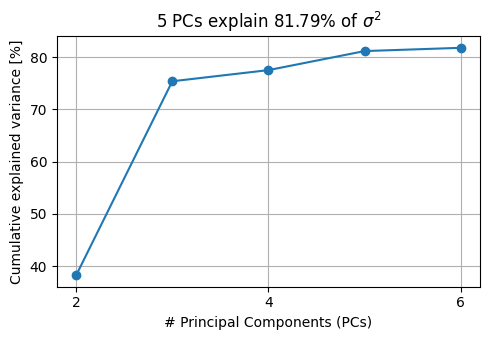

In [ ]:
# dimensionality reduction with TruncatedSVD (works with sparse matrices)
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# cannot do correlation matrix as it would be too large

n_components = 5
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_svd = svd.fit_transform(X)

# elbow method to choose number of components
explained_variance = svd.explained_variance_ratio_
cumul_exp_var = np.cumsum(explained_variance) # Get the cumulative explained variance
perc_cumul_exp_var = cumul_exp_var*100 # Get the percentages

# Plot
plt.figure(figsize=(5, 3.5))
plt.plot(perc_cumul_exp_var, marker='o')
plt.xlabel('# Principal Components (PCs)')
plt.ylabel('Cumulative explained variance [%]')
plt.xticks(np.arange(0, n_components, step=2), np.arange(2, n_components+2, step=2))
plt.grid()
plt.title(f'{len(perc_cumul_exp_var)} PCs explain {round(perc_cumul_exp_var[-1], 2)}% of $\sigma^2$')
plt.tight_layout()
plt.show()

print(f"New shape after SVD: {X_svd.shape}")
print(f"Old shape before SVD: {X.shape}")


Cluster the attacks according to their characteristics. Choose at least 2 Clustering Algorithms, and for each
of them:
1. Determine the number of clusters. Explain your choices and reasoning.
2. Tune other hyper-parameters, if any.3. Visualize the clusters. Explain your technique choice.

In [21]:
# clusering with KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
cl_labels = kmeans.fit_predict(X_svd)

# silhouette score
from sklearn.metrics import silhouette_score
silouhette = silhouette_score(X_svd, cl_labels, n_jobs=-1)
print(f'Silouhette score: {silouhette}')

KeyboardInterrupt: 